# SVM — Support Vector Machine

In [ ]:
The Story First 📖


Imagine two groups of students:
⭐ = Pass students
❌ = Fail students

Plot them on a graph:



marks
10|  ⭐  ⭐  ⭐
 8|    ⭐  ⭐
 6|  ❌    ⭐
 4|❌  ❌
 2|  ❌  ❌
  |____________
    2  4  6  8  hours

Question:
Draw a line separating ⭐ and ❌!

You can draw MANY lines!
SVM finds the BEST line!

In [ ]:

What Makes SVM Special — The Margin!


Many lines can separate the data!
But which one is BEST?

SVM finds the line with
MAXIMUM MARGIN between classes!

        ⭐  ⭐  ⭐
    ⭐  ⭐         ← Support Vectors
  - - - - - - - -  ← Decision Boundary
    ❌  ❌         ← Support Vectors
        ❌  ❌  ❌

↑margin↑   ↑margin↑

Wider margin = better generalization
= better on new data! ✅

In [ ]:
Key Terms:

Decision Boundary:
→ the line/curve separating classes
→ SVM finds BEST boundary!

Support Vectors:
→ data points closest to boundary
→ these points DEFINE the boundary!
→ if you remove other points,
   boundary stays same!
→ only support vectors matter!

Margin:
→ distance between boundary
  and nearest points of each class
→ SVM maximizes this! ✅

In [ ]:
Linear vs Non-Linear Data:

Linear data:          Non-linear data:
⭐⭐⭐ | ❌❌❌        ⭐⭐❌⭐⭐
⭐⭐  | ❌❌          ❌⭐⭐⭐❌
straight line works!  straight line fails!
                      need curved boundary!

Solution for non-linear → KERNEL TRICK! 🔥

In [ ]:
Kernel Trick — Most Important Concept!

Non-linear data in 2D:
can't separate with straight line!

Kernel trick:
→ transforms data to HIGHER dimension
→ data becomes linearly separable!
→ draw straight line in higher dimension
→ looks curved in original dimension!

Simple analogy:
Mix red and blue balls on a table (2D)
Can't separate with straight line!

Lift the table (go to 3D)
Now you can separate with a flat plane!
Kernel does exactly this! 🔥

# Types of Kernels:

"linear"  → straight line boundary
            use when data is linearly separable

"rbf"     → Radial Basis Function
            curved boundary ✅ (default, most used!)
            use for most real world data!

"poly"    → polynomial boundary
            curved but different shape

"sigmoid" → S-shaped boundary
            less common

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,
                             confusion_matrix,
                             classification_report)

# BIG dataset — Disease Prediction
np.random.seed(42)
n = 300   # 300 patients!

data = {
    "age"            : np.random.randint(20, 70, n),
    "bmi"            : np.random.uniform(18, 40, n).round(1),
    "blood_pressure" : np.random.randint(60, 140, n),
    "cholesterol"    : np.random.randint(150, 300, n),
    "blood_sugar"    : np.random.uniform(70, 200, n).round(1),
    "heart_rate"     : np.random.randint(60, 100, n),
    "exercise_hours" : np.random.uniform(0, 10, n).round(1),
    "sleep_hours"    : np.random.uniform(4, 10, n).round(1),
    "stress_level"   : np.random.randint(1, 10, n),
    "smoking"        : np.random.randint(0, 2, n),
    "alcohol"        : np.random.randint(0, 2, n),
    "family_history" : np.random.randint(0, 2, n),
}

# target → has disease or not
disease = (
    (data["age"] > 45)               &
    (data["blood_pressure"] > 100)   |
    (data["cholesterol"] > 240)      &
    (data["blood_sugar"] > 140)      |
    (data["smoking"] == 1)           &
    (data["family_history"] == 1)
).astype(int)

data["disease"] = disease
df = pd.DataFrame(data)

print("Dataset Shape:", df.shape)
print("\nDisease Distribution:")
print(df["disease"].value_counts())

Dataset Shape: (300, 13)

Disease Distribution:
disease
1    151
0    149
Name: count, dtype: int64


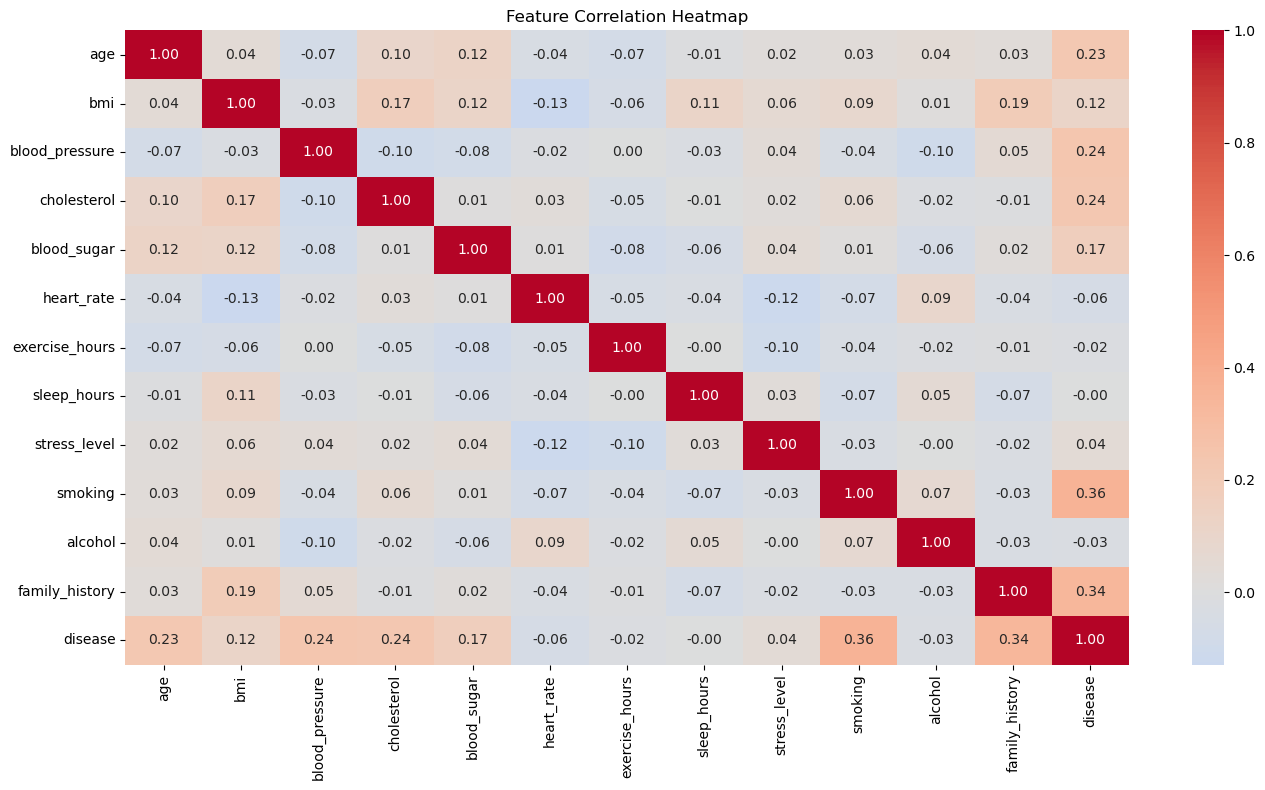

In [6]:
# EDA:

# correlation heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(df.corr(),
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Model Building:

In [ ]:
X= df.drop("disease", axis = 1)
y = df["disease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling the data 
scaler= StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# svm model
model = SVC(
    kernel="rbf",# type of boundary
    c=1.0,# regularization
    gamma="scale",# kernel coefficient
    probability=True, # enable predict_proba
    random_state=42
)
model.fit(X_train,y_train)
